# Normal_Gravity_correction


Here, we show how to use 'boule' https://www.fatiando.org/boule/latest/ to correct normal gravity

See https://www.fatiando.org/harmonica/latest/user_guide/gravity_disturbance.html#gravity-disturbance and https://github.com/LL-Geo/PFToolbox/blob/master/Gravity%20disturbance%20and%20FAA.ipynb for more information

In [1]:
# Load necessary package 
import boule as bl
import pandas as pd
import pyproj
import matplotlib.pyplot as plt
import numpy as np

# Read in Gravity data after drift correction

In [2]:
#Read in Gravity data after drift correction
Data = pd.read_csv('Processed_Data.csv', delimiter=r',')

In [3]:
# Let's looks few line of the data
Data.head(5)

,Unnamed: 0,Name,seconds_elapsed,Gravity_non_drift,Longitude,Latitude,ELLipSoidaL height,grav_drift
0,0,L1_S100,1470.0,1.248401e+06,116.215892,-31.521237,218.952,-0.766230
1,1,L1_S200,1775.5,1.248401e+06,116.214864,-31.521183,216.100,0.020231
2,2,L1_S300,2093.0,1.248402e+06,116.213828,-31.521228,211.371,0.737294
3,3,L1_S400,2457.5,1.248402e+06,116.212786,-31.521207,210.479,0.717150
4,4,L1_S500,2684.0,1.248402e+06,116.211679,-31.521218,211.715,0.249746


# Compute normal gravity at each location
Boule implements closed-form formula of Li & Gotze, 2001 which can calculate normal gravity at any latitude and (geometric) height.

Li, X. and H. J. Gotze, 2001, Tutorial: Ellipsoid, geoid, gravity, geodesy, and geophysics, Geophysics, 66(6), p. 1660-1668, doi:10.1190/1.1487109

In [4]:
normal_gravity = bl.WGS84.normal_gravity(Data.Latitude, Data['ELLipSoidaL height'])
disturbance = Data['grav_drift'] - normal_gravity + 9.79378e5

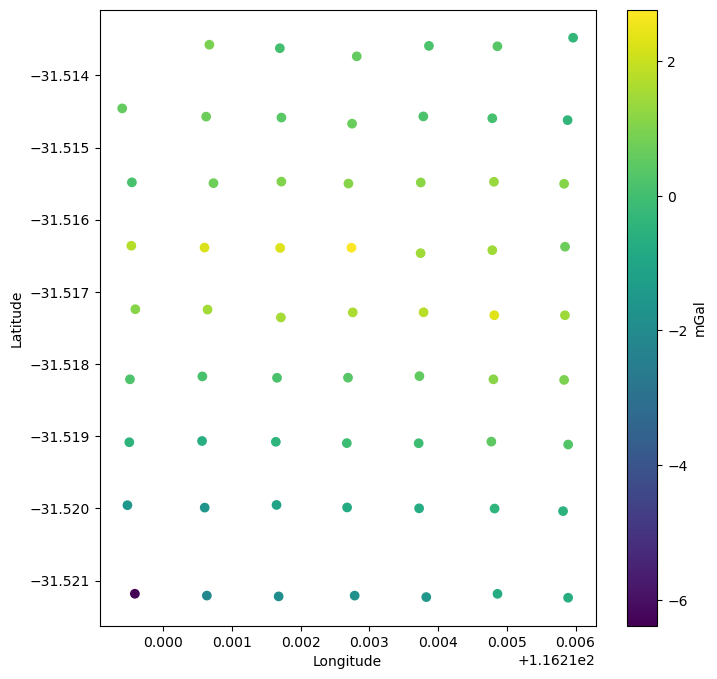

In [5]:
plt.figure(figsize=(8, 8))
# Scatter plot for Combine_data with color mapping based on 'GRAV.' values
sc = plt.scatter(Data['Longitude'], Data['Latitude'], c=disturbance, cmap='viridis')
# Add labels and legend
plt.xlabel('Longitude')
plt.ylabel('Latitude')
# Add colorbar to the plot
plt.colorbar(sc, label='mGal')
# Show the plot
plt.show()

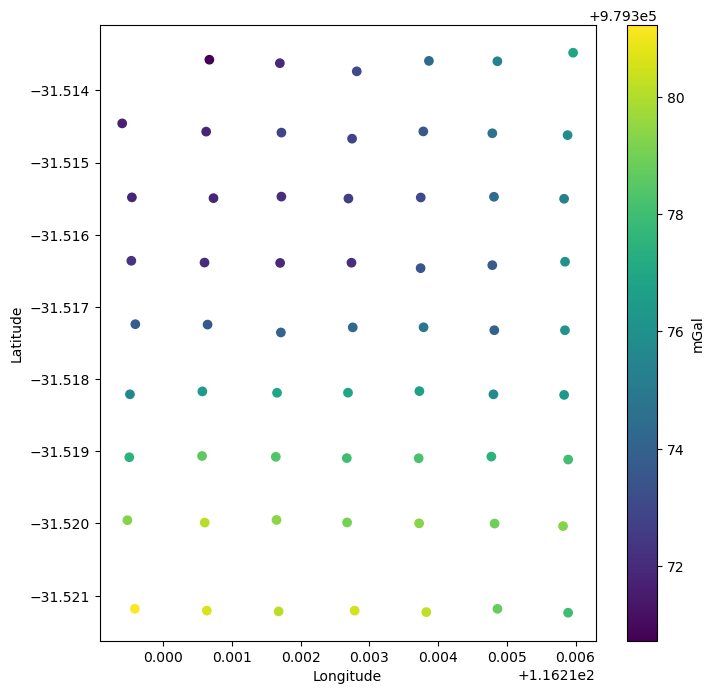

In [6]:
plt.figure(figsize=(8, 8))
# Scatter plot for Combine_data with color mapping based on 'GRAV.' values
sc = plt.scatter(Data['Longitude'], Data['Latitude'], c=normal_gravity, cmap='viridis')
# Add labels and legend
plt.xlabel('Longitude')
plt.ylabel('Latitude')
# Add colorbar to the plot
plt.colorbar(sc, label='mGal')
# Show the plot
plt.show()

In [7]:
# Save the Data to a CSV file
data_array = np.column_stack((Data['Name'], Data['Longitude'], Data['Latitude'], Data['ELLipSoidaL height'], Data['grav_drift'], disturbance))
df = pd.DataFrame(data_array, columns=['Name','Lon', 'Lat', 'Height_Ellipsoid', 'Total Gravity', 'Free Air Disturbance'])
df.to_csv('Free_Air_Grav_CAGE_FIELD.csv', index=False)

In [8]:
df

,Name,Lon,Lat,Height_Ellipsoid,Total Gravity,Free Air Disturbance
0,L1_S100,116.215892,-31.521237,218.952,-0.76623,-0.674237
1,L1_S200,116.214864,-31.521183,216.1,0.020231,-0.763659
2,L1_S300,116.213828,-31.521228,211.371,0.737294,-1.509716
3,L1_S400,116.212786,-31.521207,210.479,0.71715,-1.803505
4,L1_S500,116.211679,-31.521218,211.715,0.249746,-1.89032
...,...,...,...,...,...,...
57,L9_S200,116.214863,-31.513597,225.15,-2.261085,0.358826
58,L9_S300,116.213867,-31.513592,228.46,-3.482005,0.159895
59,L9_S400,116.212816,-31.513737,232.575,-4.346265,0.553982
60,L9_S500,116.211697,-31.513624,236.2,-6.013016,0.015081


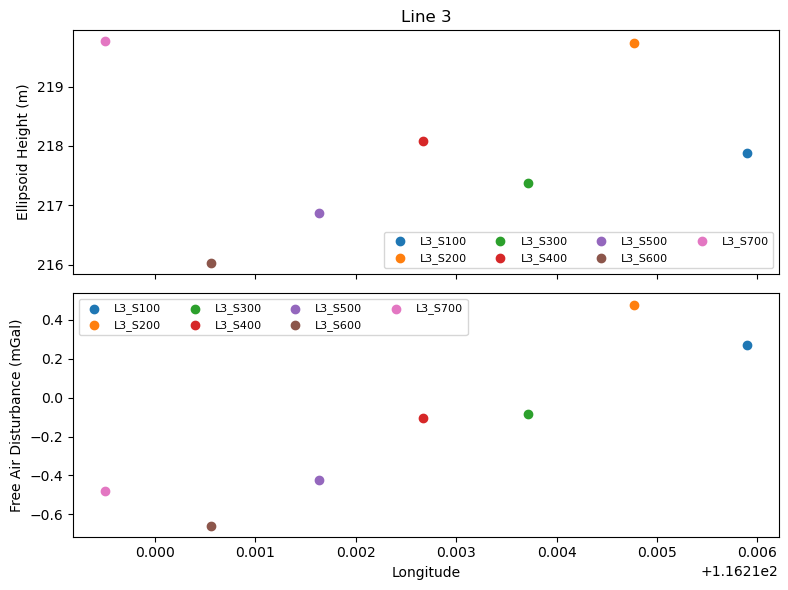

In [9]:
line_number = 3

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True
)

for station in range(100, 701, 100):
    name = f"L{line_number}_S{station}"

    mask = df.Name == name

    # Height profile
    ax1.scatter(
        df.loc[mask, 'Lon'],
        df.loc[mask, 'Height_Ellipsoid'],
        label=name
    )

    # Free-air disturbance profile
    ax2.scatter(
        df.loc[mask, 'Lon'],
        df.loc[mask, 'Free Air Disturbance'],
        label=name
    )

ax1.set_ylabel('Ellipsoid Height (m)')
ax1.set_title(f'Line {line_number}')

ax2.set_xlabel('Longitude')
ax2.set_ylabel('Free Air Disturbance (mGal)')

ax1.legend(ncol=4, fontsize=8)
ax2.legend(ncol=4, fontsize=8)

plt.tight_layout()
plt.show()

In the next notebook, we will show how to remove topography signal to get Bouguer gravity (aka topography free disturbance)